In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import sys
sys.path.append('../')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score,
    confusion_matrix
)
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from src.evaluate import evaluate_model

%matplotlib inline
print("All imports successful!")

All imports successful!


In [2]:
X_train = pd.read_csv('../data/processed/X_train_creditcard.csv')
X_test  = pd.read_csv('../data/processed/X_test_creditcard.csv')
y_train = pd.read_csv('../data/processed/y_train_creditcard.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test_creditcard.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\ny_train fraud rate: {y_train.mean()*100:.2f}%  (should be ~50% after SMOTE)")
print(f"y_test  fraud rate: {y_test.mean()*100:.4f}%  (should be ~0.17% real world)")

X_train: (454902, 30)
X_test:  (56962, 30)

y_train fraud rate: 50.00%  (should be ~50% after SMOTE)
y_test  fraud rate: 0.1720%  (should be ~0.17% real world)


In [3]:
# Logistic Regression
print("Training Logistic Regression...")
lr_cc = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_cc.fit(X_train, y_train)
print("Done!")
lr_results = evaluate_model(lr_cc, X_test, y_test, "Logistic Regression (Baseline)")

# XGBoost
print("\nTraining XGBoost...")
xgb_cc = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='aucpr', verbosity=0
)
xgb_cc.fit(X_train, y_train)
print("Done!")
xgb_results = evaluate_model(xgb_cc, X_test, y_test, "XGBoost")

# LightGBM
print("\nTraining LightGBM...")
lgb_cc = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=-1
)
lgb_cc.fit(X_train, y_train)
print("Done!")
lgb_results = evaluate_model(lgb_cc, X_test, y_test, "LightGBM")

Training Logistic Regression...
Done!

  Logistic Regression (Baseline)
  AUC-PR (main metric):  0.7249
  AUC-ROC:               0.9698
  F1-Score:              0.1094
  Precision:             0.0581
  Recall:                0.9184

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            55406             1458
Actual Fraud                8               90

  True Positives  (fraud caught):        90
  False Negatives (fraud missed):        8  ← costly!
  False Positives (legit flagged wrong): 1458  ← frustrating
  True Negatives  (legit correct):       55406

Training XGBoost...
Done!

  XGBoost
  AUC-PR (main metric):  0.8786
  AUC-ROC:               0.9799
  F1-Score:              0.8056
  Precision:             0.7373
  Recall:                0.8878

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            56833               31
Actual Fraud               11               87

  True Positives  (fraud caught):        8


MODEL COMPARISON — creditcard.csv
                                AUC-PR  AUC-ROC      F1  Precision  Recall  Fraud Caught (TP)  Fraud Missed (FN)
model                                                                                                           
Logistic Regression (Baseline)  0.7249   0.9698  0.1094     0.0581  0.9184                 90                  8
XGBoost                         0.8786   0.9799  0.8056     0.7373  0.8878                 87                 11
LightGBM                        0.8453   0.9614  0.7757     0.7155  0.8469                 83                 15


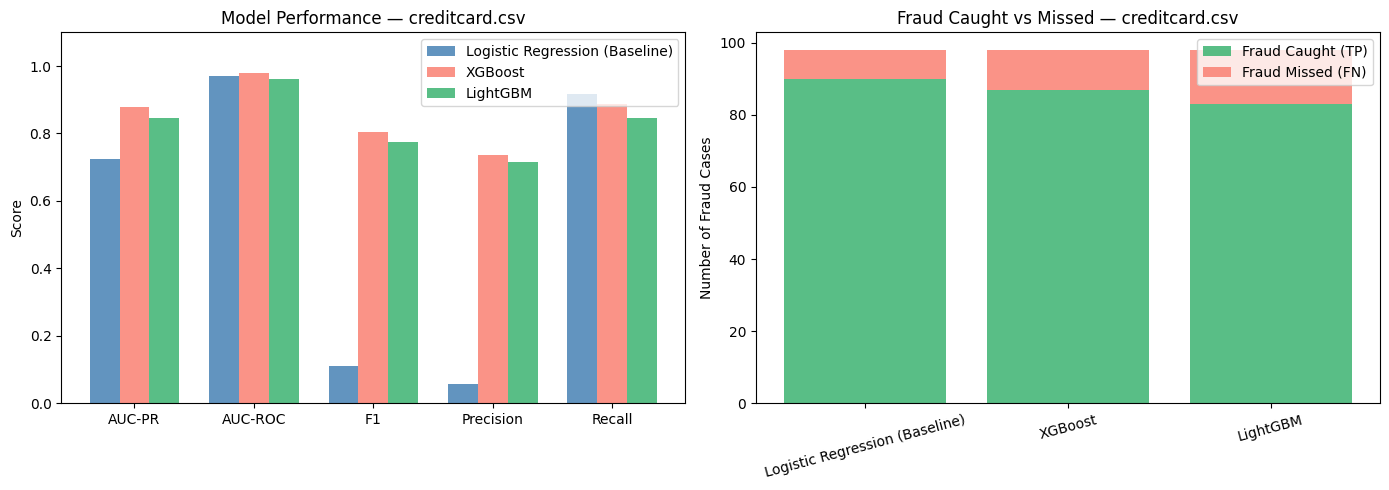

In [4]:
results_df = pd.DataFrame([lr_results, xgb_results, lgb_results])
results_df = results_df.set_index('model')

print("\n" + "="*70)
print("MODEL COMPARISON — creditcard.csv")
print("="*70)
print(results_df.to_string())

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['AUC-PR', 'AUC-ROC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'salmon', 'mediumseagreen']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i*width, [row[m] for m in metrics],
                width, label=model_name, color=colors[i], alpha=0.85)

axes[0].set_title('Model Performance — creditcard.csv')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')

caught = results_df['Fraud Caught (TP)'].values
missed = results_df['Fraud Missed (FN)'].values
models = results_df.index.tolist()

axes[1].bar(models, caught, color='mediumseagreen', label='Fraud Caught (TP)', alpha=0.85)
axes[1].bar(models, missed, bottom=caught, color='salmon',
            label='Fraud Missed (FN)', alpha=0.85)
axes[1].set_title('Fraud Caught vs Missed — creditcard.csv')
axes[1].set_ylabel('Number of Fraud Cases')
axes[1].legend()
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [5]:
# Recover pre-SMOTE real rows
X_train_real = X_train.iloc[:227845]
y_train_real = y_train.iloc[:227845]

print(f"Pre-SMOTE fraud rate: {y_train_real.mean()*100:.4f}%")
# Should be ~0.17%

def cross_val_with_smote(model, X, y, cv, model_name):
    scores = {'f1': [], 'auc_roc': [], 'precision': [], 'recall': []}
    X_np = X.values
    y_np = y.values

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_np, y_np)):
        X_fold_train, y_fold_train = X_np[train_idx], y_np[train_idx]
        X_fold_val,   y_fold_val   = X_np[val_idx],   y_np[val_idx]

        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

        model.fit(X_resampled, y_resampled)
        y_pred  = model.predict(X_fold_val)
        y_proba = model.predict_proba(X_fold_val)[:, 1]

        scores['f1'].append(f1_score(y_fold_val, y_pred))
        scores['auc_roc'].append(roc_auc_score(y_fold_val, y_proba))
        scores['precision'].append(precision_score(y_fold_val, y_pred))
        scores['recall'].append(recall_score(y_fold_val, y_pred))
        print(f"  Fold {fold+1} done — F1: {scores['f1'][-1]:.4f}")

    print(f"\n{model_name} CV Summary:")
    for metric, vals in scores.items():
        print(f"  {metric:<12} mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")
    return scores

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_cv_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=-1
)
xgb_cv_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='aucpr', verbosity=0
)

print("\nRunning corrected CV for LightGBM (5 folds)...")
lgb_cv_scores = cross_val_with_smote(
    lgb_cv_model, X_train_real, y_train_real, cv, "LightGBM"
)

print("\nRunning corrected CV for XGBoost (5 folds)...")
xgb_cv_scores = cross_val_with_smote(
    xgb_cv_model, X_train_real, y_train_real, cv, "XGBoost"
)

print("\n" + "="*72)
print("CORRECTED CV Results — creditcard.csv")
print("="*72)
print(f"\n{'Metric':<15} {'LightGBM Mean':>15} {'LightGBM Std':>14} "
      f"{'XGBoost Mean':>14} {'XGBoost Std':>12}")
print("-"*72)
for metric in ['f1', 'auc_roc', 'precision', 'recall']:
    lm = np.mean(lgb_cv_scores[metric])
    ls = np.std(lgb_cv_scores[metric])
    xm = np.mean(xgb_cv_scores[metric])
    xs = np.std(xgb_cv_scores[metric])
    print(f"{metric:<15} {lm:>14.4f}  {ls:>13.4f}  {xm:>13.4f}  {xs:>11.4f}")

Pre-SMOTE fraud rate: 0.1729%

Running corrected CV for LightGBM (5 folds)...
  Fold 1 done — F1: 0.8000
  Fold 2 done — F1: 0.8077
  Fold 3 done — F1: 0.7778
  Fold 4 done — F1: 0.7541
  Fold 5 done — F1: 0.8075

LightGBM CV Summary:
  f1           mean=0.7894  std=0.0208
  auc_roc      mean=0.9738  std=0.0088
  precision    mean=0.7628  std=0.0532
  recall       mean=0.8223  std=0.0277

Running corrected CV for XGBoost (5 folds)...
  Fold 1 done — F1: 0.7758
  Fold 2 done — F1: 0.8258
  Fold 3 done — F1: 0.7326
  Fold 4 done — F1: 0.7701
  Fold 5 done — F1: 0.8098

XGBoost CV Summary:
  f1           mean=0.7828  std=0.0326
  auc_roc      mean=0.9807  std=0.0090
  precision    mean=0.7415  std=0.0661
  recall       mean=0.8350  std=0.0402

CORRECTED CV Results — creditcard.csv

Metric            LightGBM Mean   LightGBM Std   XGBoost Mean  XGBoost Std
------------------------------------------------------------------------
f1                      0.7894         0.0208         0.7828  

In [6]:
os.makedirs('../models', exist_ok=True)

joblib.dump(lgb_cc, '../models/lightgbm_creditcard.pkl')
joblib.dump(xgb_cc, '../models/xgboost_creditcard.pkl')
joblib.dump(lr_cc,  '../models/logistic_regression_creditcard.pkl')

feature_names_cc = X_train.columns.tolist()
joblib.dump(feature_names_cc, '../models/feature_names_creditcard.pkl')

print("✅ Models saved:")
print("   lightgbm_creditcard.pkl")
print("   xgboost_creditcard.pkl")
print("   logistic_regression_creditcard.pkl")
print("   feature_names_creditcard.pkl")

✅ Models saved:
   lightgbm_creditcard.pkl
   xgboost_creditcard.pkl
   logistic_regression_creditcard.pkl
   feature_names_creditcard.pkl
